# Bước 3: Đánh giá, So sánh & Phân tích Phân khúc Khách hàng

Notebook này thực hiện việc đánh giá và so sánh các mô hình phân cụm tối ưu. Sau khi số cụm tối ưu $K = 4$, linkage='ward' được xác định ở Bước 2, chúng ta tiến hành huấn luyện mô hình scikit-learn đối chứng tương ứng để đảm bảo đối chiếu song song 1:1 trên Leaderboard. Cuối cùng, thực hiện trực quan hóa PCA, kiểm chứng ngoại bộ (ARI, NMI) và phân tích chân dung phân khúc khách hàng.

## 1. Khai báo thư viện và đường dẫn hệ thống

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import joblib
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score

# Thêm đường dẫn gốc của dự án để import general_utils
sys.path.append(os.path.abspath('../../'))
from general_utils.model_manager import save_model_package, generate_report

# Import class tự viết để joblib giải tuần tự hóa thành công
from hierarchical_clustering_scratch import HierarchicalClusteringScratch

sns.set_theme(style='whitegrid')

## 2. Tải dữ liệu mẫu 1000 dòng

In [2]:
# Tải dữ liệu sạch và nhãn
X_preprocessed = joblib.load('data/ready_for_train/X_preprocessed.pkl')
y = joblib.load('data/ready_for_train/y.pkl')

# Sử dụng cùng một tập mẫu 1000 dòng để so sánh công bằng
np.random.seed(42)
sample_indices = np.random.choice(X_preprocessed.shape[0], 1000, replace=False)
X_sample = X_preprocessed[sample_indices]
y_sample = y.iloc[sample_indices].reset_index(drop=True)

# Tải dữ liệu thô phục vụ profiling
df_raw = pd.read_csv('../data/raw/Train.csv')
df_raw_sample = df_raw.iloc[sample_indices].reset_index(drop=True)

print(f"X_sample shape: {X_sample.shape}")

X_sample shape: (1000, 26)


## 3. Huấn luyện và Đóng gói duy nhất 1 mô hình scikit-learn tối ưu

Chúng ta tiến hành huấn luyện mô hình scikit-learn (`AgglomerativeClustering`) đối chứng trên cấu hình tối ưu đã thống nhất ($K = 4$, linkage='ward') để đối chiếu công bằng với mô hình tự viết.

In [3]:
best_k = 4
best_linkage = 'ward'

print(f"Huấn luyện mô hình scikit-learn đối chứng với linkage = '{best_linkage}', K = {best_k}...")

model_sklearn = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
labels = model_sklearn.fit_predict(X_sample)
score = silhouette_score(X_sample, labels)
print(f"-> Silhouette Score: {score:.4f}")

# Đóng gói và lưu trữ
best_params = {
    'n_clusters': best_k,
    'linkage': best_linkage
}
metrics = {
    'Silhouette': score
}

file_path = save_model_package(
    model=model_sklearn,
    model_name="hierarchical_sklearn_best",
    best_params=best_params,
    metrics=metrics,
    save_dir='models'
)
print(f"-> Lưu thành công tại: {file_path}")

Huấn luyện mô hình scikit-learn đối chứng với linkage = 'ward', K = 4...
-> Silhouette Score: 0.1530
-> Lưu thành công tại: models/hierarchical_sklearn_best.pkl


## 4. So sánh các mô hình và Xuất bảng xếp hạng (Leaderboard)

Hàm `generate_report` hiển thị so sánh đối chiếu giữa mô hình tự viết và mô hình thư viện trên cùng hệ quy chiếu tối ưu.

In [4]:
df_leaderboard = generate_report(model_dir='models')
df_leaderboard

-> Skip file pca_transformer.pkl vì lỗi cấu trúc gói. Chi tiết: 'PCA' object has no attribute 'get'
-> Skip file preprocessor.pkl vì lỗi cấu trúc gói. Chi tiết: 'ColumnTransformer' object has no attribute 'get'


,Mô hình,Silhouette,Tham số tốt nhất
0,hierarchical_scratch_best,0.152979,"{'n_clusters': 4, 'linkage': 'ward'}"
1,hierarchical_sklearn_best,0.152979,"{'n_clusters': 4, 'linkage': 'ward'}"


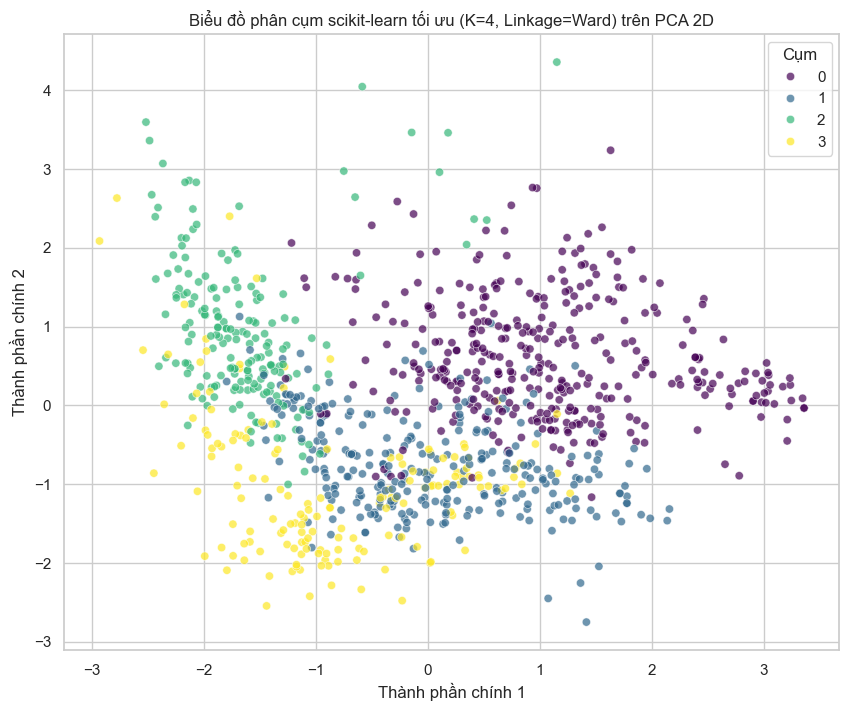

In [5]:
# Tải lại bộ giảm chiều PCA đã lưu
pca = joblib.load('models/pca_transformer.pkl')
X_pca_sample = pca.transform(X_sample)

# Chạy mô hình tối ưu để trực quan hóa cụm phân tách
best_sklearn = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
labels_best = best_sklearn.fit_predict(X_sample)

# Trực quan hóa các phân cụm dự đoán trên không gian PCA 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca_sample[:, 0], y=X_pca_sample[:, 1], hue=labels_best, palette='viridis', alpha=0.7)
plt.title(f'Biểu đồ phân cụm scikit-learn tối ưu (K={best_k}, Linkage=Ward) trên PCA 2D')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.legend(title='Cụm')
plt.savefig('plots/clusters_pca_2d.png')
plt.show()

## 5. Kiểm chứng nhãn (External Validation)

Đối chiếu nhãn phân cụm tự nhiên của mô hình tối ưu với cột nhãn `Segmentation` gốc bằng các chỉ số tương đồng (ARI, NMI) để kiểm chứng tính đúng đắn của phương pháp.

In [6]:
# Tính toán chỉ số tương đồng ARI và NMI so với nhãn Segmentation
ari_score = adjusted_rand_score(y_sample, labels_best)
nmi_score = normalized_mutual_info_score(y_sample, labels_best)

print(f"Kết quả kiểm chứng phân cụm so với nhãn Segmentation thực tế:")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

Kết quả kiểm chứng phân cụm so với nhãn Segmentation thực tế:
Adjusted Rand Index (ARI): 0.0800
Normalized Mutual Information (NMI): 0.0957


## 6. Phân tích chân dung khách hàng cho từng phân khúc (Profiling)

In [7]:
# Gán các nhãn cụm vào tập mẫu thô phục vụ phân tích hồ sơ
df_profile = df_raw_sample.copy()
df_profile = df_profile.drop(columns=['ID', 'Segmentation'])
df_profile['Cluster'] = labels_best

# Phân tích số lượng khách hàng từng cụm
print("--- Số lượng mẫu mỗi cụm ---")
print(df_profile['Cluster'].value_counts())


--- Số lượng mẫu mỗi cụm ---
Cluster
0    367
1    287
2    186
3    160
Name: count, dtype: int64


### 6.1. Thống kê chi tiết các đặc trưng số theo cụm
Tính toán các thông số thống kê mô tả bao gồm: trung bình (mean), trung vị (median), độ lệch chuẩn (std), giá trị nhỏ nhất (min) và lớn nhất (max) cho các biến số `Age`, `Work_Experience`, và `Family_Size`.

In [8]:
# Phân tích chi tiết các đặc trưng số theo cụm (mean, median, std, min, max)
print("--- Thống kê chi tiết các đặc trưng số theo cụm ---")
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']
for col in numerical_cols:
    print(f"\nĐặc trưng: {col}")
    stats_df = df_profile.groupby('Cluster')[col].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
    print(stats_df)


--- Thống kê chi tiết các đặc trưng số theo cụm ---

Đặc trưng: Age
          mean  median    std  min  max
Cluster                                
0        50.22    48.0  14.98   18   89
1        47.65    43.0  16.89   18   89
2        26.69    25.0   8.63   18   76
3        35.67    36.0   8.70   19   66

Đặc trưng: Work_Experience
         mean  median   std  min   max
Cluster                               
0        1.70     1.0  2.36  0.0  10.0
1        1.13     1.0  1.75  0.0  13.0
2        0.97     1.0  1.36  0.0   6.0
3        8.14     8.0  1.95  3.0  14.0

Đặc trưng: Family_Size
         mean  median   std  min  max
Cluster                              
0        3.12     3.0  1.19  1.0  7.0
1        1.78     2.0  0.88  1.0  5.0
2        4.43     4.0  1.73  1.0  9.0
3        2.37     2.0  1.54  1.0  9.0


### 6.2. Trực quan hóa phân bố đặc trưng số bằng Boxplot
Sử dụng biểu đồ Boxplot để trực quan hóa sự phân bố và nhận diện các giá trị ngoại lệ của các đặc trưng số giữa các phân cụm khách hàng.

/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_92602/2483173740.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_profile, ax=axes[i], palette='Set2')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_92602/2483173740.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_profile, ax=axes[i], palette='Set2')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_92602/2483173740.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_profi

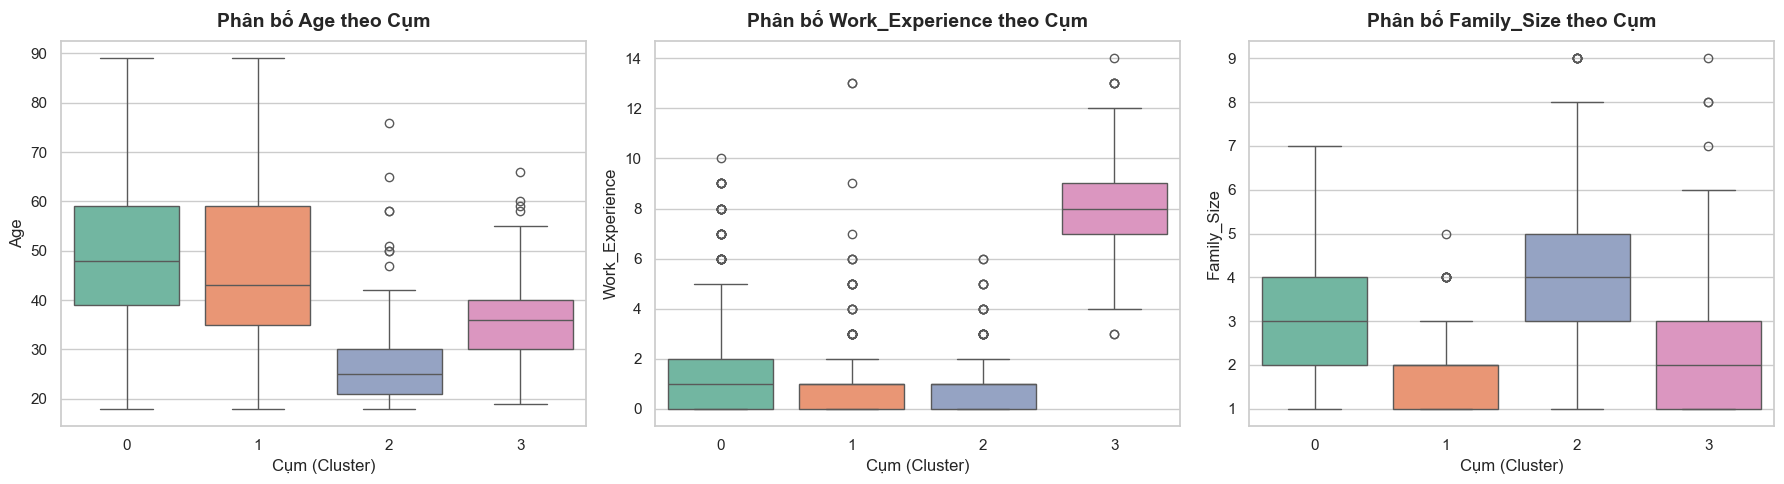

In [9]:
# Vẽ boxplot phân bố biến số cho các đặc trưng theo cụm
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']
for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Cluster', y=col, data=df_profile, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Phân bố {col} theo Cụm', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Cụm (Cluster)', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)
plt.tight_layout()
plt.savefig('plots/profiling_numerical.png', dpi=300)
plt.show()


### 6.3. Phân tích phân bố các thuộc tính định tính (%)
Tính toán tỷ lệ phần trăm phân bố chéo của các thuộc tính định tính bao gồm `Gender`, `Ever_Married`, `Spending_Score`, và `Profession` theo từng cụm khách hàng.

In [10]:
# Phân tích phân bố các thuộc tính định tính (%)
for col in ['Gender', 'Ever_Married', 'Spending_Score', 'Profession']:
    print(f"\n--- Phân tích phân khúc theo {col} (%) ---")
    print(pd.crosstab(df_profile['Cluster'], df_profile[col], normalize='index').round(2) * 100)



--- Phân tích phân khúc theo Gender (%) ---
Gender   Female  Male
Cluster              
0          38.0  62.0
1          48.0  52.0
2          47.0  53.0
3          59.0  41.0

--- Phân tích phân khúc theo Ever_Married (%) ---
Ever_Married    No    Yes
Cluster                  
0              0.0  100.0
1             49.0   51.0
2             92.0    8.0
3             59.0   41.0

--- Phân tích phân khúc theo Spending_Score (%) ---
Spending_Score  Average  High   Low
Cluster                            
0                  55.0  37.0   8.0
1                   2.0   0.0  98.0
2                   4.0   1.0  96.0
3                  22.0   2.0  76.0

--- Phân tích phân khúc theo Profession (%) ---
Profession  Artist  Doctor  Engineer  Entertainment  Executive  Healthcare  \
Cluster                                                                      
0             42.0     4.0       8.0           15.0       13.0         4.0   
1             35.0    10.0      11.0           15.0        1.0  

### 6.4. Trực quan hóa đặc trưng định tính bằng 100% Stacked Bar Chart
Vẽ biểu đồ cột chồng 100% để trực quan hóa rõ nét cơ cấu thành phần của các thuộc tính định tính trong từng phân cụm khách hàng.

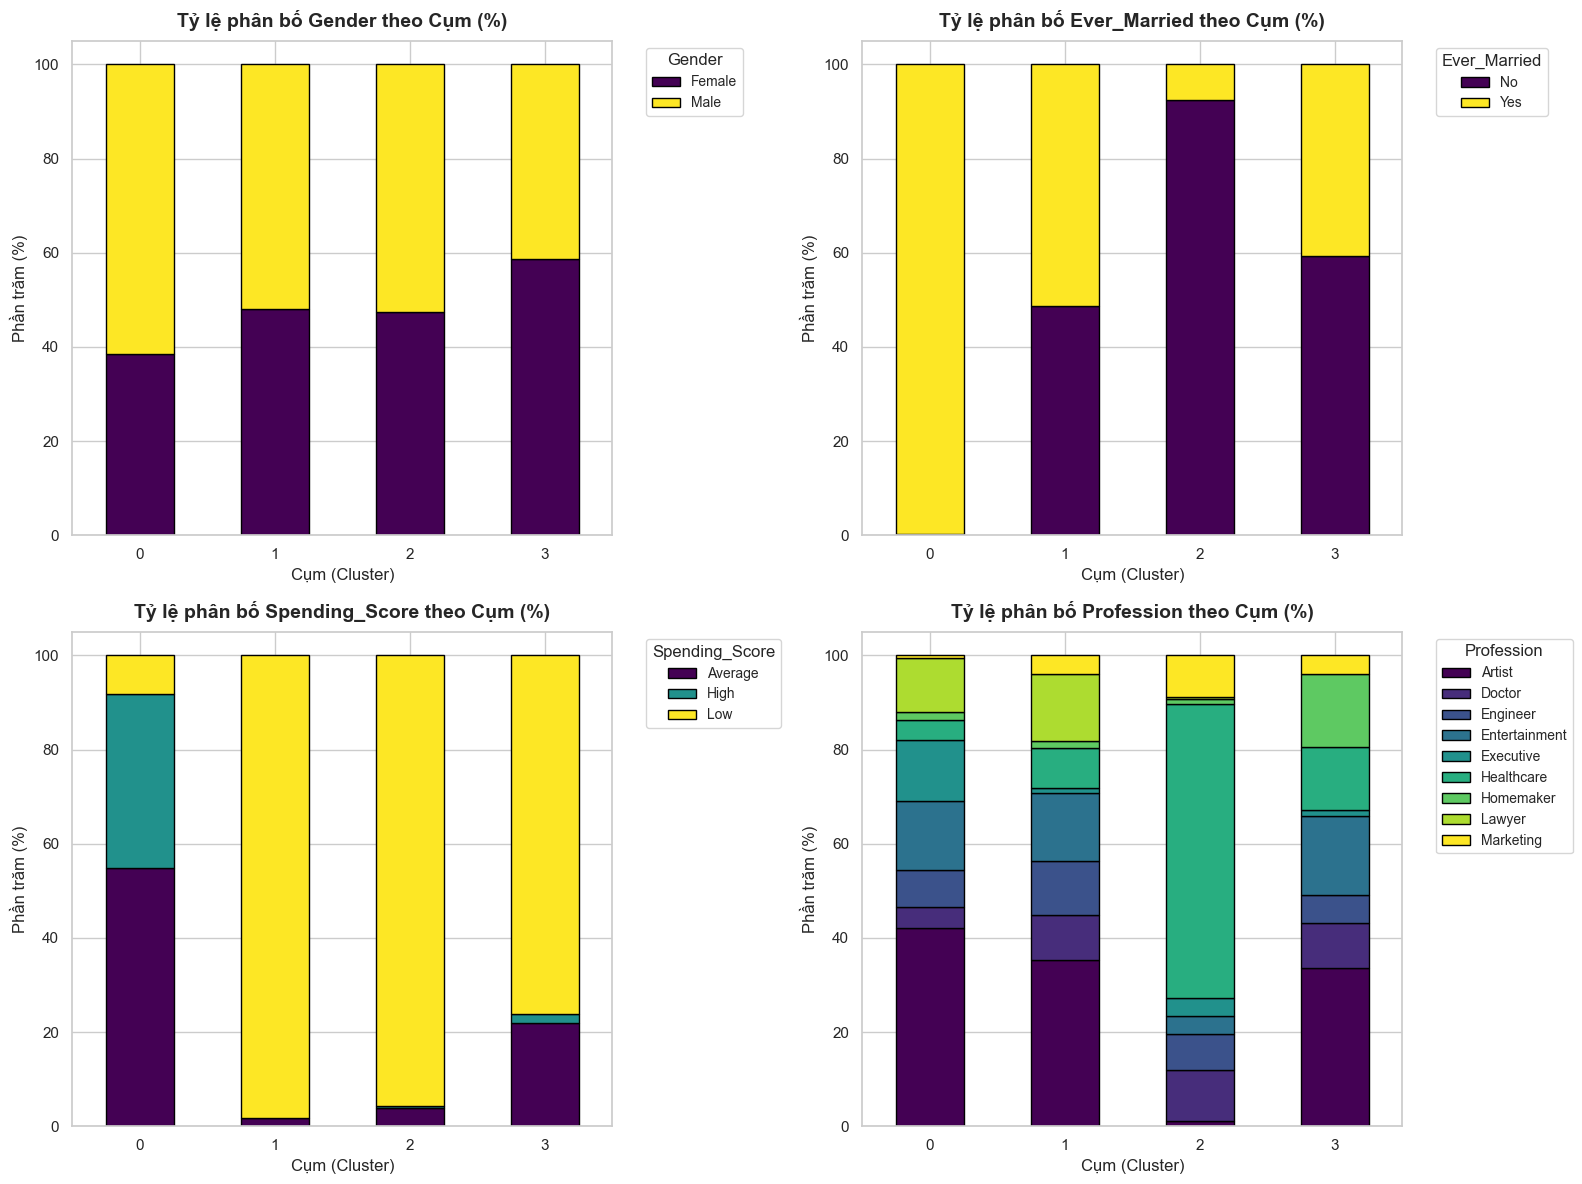

In [11]:
# Vẽ biểu đồ cột chồng 100% cho các thuộc tính định tính theo từng cụm
categorical_cols = ['Gender', 'Ever_Married', 'Spending_Score', 'Profession']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df_profile['Cluster'], df_profile[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='black')
    axes[i].set_title(f'Tỷ lệ phân bố {col} theo Cụm (%)', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Cụm (Cluster)', fontsize=12)
    axes[i].set_ylabel('Phần trăm (%)', fontsize=12)
    axes[i].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('plots/profiling_categorical.png', dpi=300)
plt.show()
